# Energy Conservation Diagnostics

Generates `pde_energy_conservation.pdf` and `pde_energy_conservation_photon.pdf` (Figure 10 in paper).

Left panel: heat injection. Right panel: photon injection at three x_inj.

Heat injection energy conservation
Energy conservation: min=-0.3523%, max=-0.0664%
RMS = 0.1992%


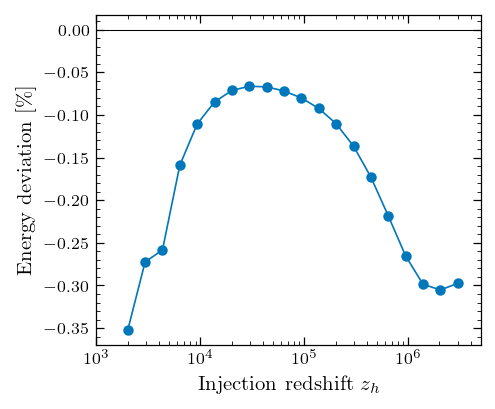

In [1]:
import os
from pathlib import Path

# Ensure cargo is on PATH
cargo_bin = Path.home() / '.cargo' / 'bin'
if cargo_bin.is_dir() and str(cargo_bin) not in os.environ.get('PATH', ''):
    os.environ['PATH'] = str(cargo_bin) + os.pathsep + os.environ.get('PATH', '')

PROJECT_ROOT = Path.cwd().parent.parent
FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(exist_ok=True)


# Produces two figures:
# 1. pde_energy_conservation.pdf — heat injection
# 2. pde_energy_conservation_photon.pdf — photon injection at 3 x_inj values

# Uses drho from the snapshot (which includes 4*accumulated_delta_t from
# the temperature-shift subtraction) as the total recovered energy.

import numpy as np
from pathlib import Path


from spectroxide import ALPHA_RHO, G3_PLANCK
from spectroxide.solver import run_sweep, run_photon_sweep
from spectroxide.style import apply_style, C, SINGLE_COL
import matplotlib.pyplot as plt

apply_style()


# ================================================================
# Figure 1: Heat injection energy conservation
# ================================================================
print("=" * 60)
print("Heat injection energy conservation")
print("=" * 60)

delta_rho_inj = 1e-5
z_heat = np.geomspace(2e3, 3e6, 20).tolist()

data = run_sweep(
    delta_rho=delta_rho_inj,
    z_injections=z_heat,
    n_points=8000,
    number_conserving=True,
    timeout=12000,
    dtau_max=3,
)

z_h = np.array([r["z_h"] for r in data["results"]])
drho = np.array([r["drho"] for r in data["results"]])
energy_pct = (drho / delta_rho_inj - 1.0) * 100

fig, ax = plt.subplots(figsize=(SINGLE_COL, 2.8))
ax.plot(z_h, energy_pct, "o-", ms=4, color=C["blue"], lw=0.8)
ax.axhline(0.0, color="k", lw=0.5, ls="-")
ax.set_xlabel(r"Injection redshift $z_h$")
ax.set_ylabel(r"Energy deviation [\%]")
ax.set_xscale("log")
ax.set_xlim(1e3, 5e6)
fig.tight_layout()
fig.savefig(FIG_DIR / "pde_energy_conservation.pdf")
# plt.close()

print(f"Energy conservation: min={energy_pct.min():.4f}%, max={energy_pct.max():.4f}%")
print(f"RMS = {np.sqrt(np.mean(energy_pct**2)):.4f}%")
# print(f"Saved to {FIG_DIR / 'pde_energy_conservation.pdf'}")



## Photon injection energy conservation


Photon injection energy conservation

x_inj = 0.5, drho_inj = 1.8510e-06
  z_h=3.00e+03  drho=1.8503e-06  4*dT=0.0000e+00  dev=-0.04%
  z_h=6.18e+03  drho=1.8499e-06  4*dT=0.0000e+00  dev=-0.06%
  z_h=1.27e+04  drho=1.8495e-06  4*dT=0.0000e+00  dev=-0.08%
  z_h=2.62e+04  drho=1.8491e-06  4*dT=0.0000e+00  dev=-0.10%
  z_h=5.40e+04  drho=1.8490e-06  4*dT=1.2896e-05  dev=-0.11%
  z_h=1.11e+05  drho=1.8496e-06  4*dT=1.3330e-05  dev=-0.08%
  z_h=2.29e+05  drho=1.8510e-06  4*dT=1.3254e-05  dev=-0.00%
  z_h=4.72e+05  drho=1.8551e-06  4*dT=1.2864e-05  dev=0.22%
  z_h=9.71e+05  drho=1.8656e-06  4*dT=1.1270e-05  dev=0.79%
  z_h=2.00e+06  drho=1.8687e-06  4*dT=5.7030e-06  dev=0.95%

x_inj = 3.0, drho_inj = 1.1106e-05
  z_h=3.00e+03  drho=1.1106e-05  4*dT=0.0000e+00  dev=-0.01%
  z_h=6.18e+03  drho=1.1105e-05  4*dT=0.0000e+00  dev=-0.01%
  z_h=1.27e+04  drho=1.1105e-05  4*dT=0.0000e+00  dev=-0.01%
  z_h=2.62e+04  drho=1.1104e-05  4*dT=0.0000e+00  dev=-0.02%
  z_h=5.40e+04  drho=1.1104e-05  4*dT=1

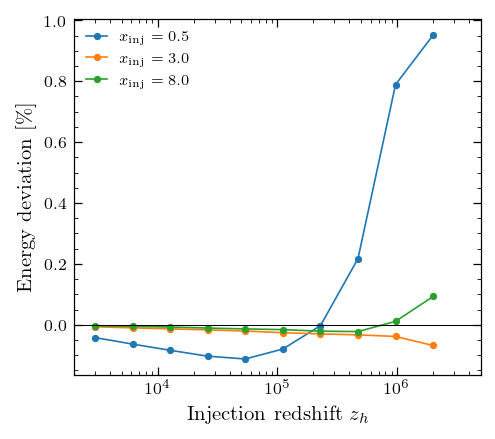

In [2]:
# Photon injection energy conservation
# ================================================================
print("\n" + "=" * 60)
print("Photon injection energy conservation")
print("=" * 60)

x_inj_values = [0.5, 3.0, 8.0]
z_injections = np.geomspace(3e3, 2e6, 10).tolist()
# z_injections = np.array([2e6])
delta_n_over_n = 1e-5
fig, ax = plt.subplots(figsize=(SINGLE_COL, 3.0))

for x_inj in x_inj_values:
    drho_inj = ALPHA_RHO * x_inj * delta_n_over_n

    print(f"\nx_inj = {x_inj}, drho_inj = {drho_inj:.4e}")
    result = run_photon_sweep(
        x_inj,
        delta_n_over_n=delta_n_over_n,
        z_injections=z_injections,
        n_points=8000,
        number_conserving=True,
        timeout=36000,
        dtau_max=3,
    )

    zh_arr = []
    energy_pct = []
    for r in result["results"]:
        zh = r["z_h"]
        # Total energy from snapshot: distortion + T-shift
        drho_pde = r["drho"]
        acc_dt = r.get("accumulated_delta_t", 0.0)
        pct = (drho_pde / drho_inj - 1.0) * 100
        zh_arr.append(zh)
        energy_pct.append(pct)
        print(f"  z_h={zh:.2e}  drho={drho_pde:.4e}  4*dT={4*acc_dt:.4e}  dev={pct:.2f}%")

    zh_arr = np.array(zh_arr)
    energy_pct = np.array(energy_pct)

    ax.plot(zh_arr, energy_pct, "o-", ms=2.5, lw=0.8, label=f"$x_{{\\rm inj}} = {x_inj}$")

ax.axhline(0.0, color="k", lw=0.5, ls="-")
ax.set_xlabel(r"Injection redshift $z_h$")
ax.set_ylabel(r"Energy deviation [\%]")
ax.set_xscale("log")
ax.legend(fontsize=7)
ax.set_xlim(2e3, 5e6)

fig.tight_layout()
fig.savefig(FIG_DIR / "pde_energy_conservation_photon.pdf")
print(f"\nSaved to {FIG_DIR / 'pde_energy_conservation_photon.pdf'}")
# plt.close()